# 01 · 热金属球多久冷却到目标温度？
**Equation to Code · 传热学入门 · Top-down 实验**

先运行一个完整例子，再改参数，最后拆开物理、数学与程序。会 Python 变量、函数和循环即可，不要求 Class 或机器学习框架。

**默认模型结果：约 356 秒（5.93 分钟）从 80 °C 冷却至 40 °C。** 这是指定假设下的计算，不是测量或真实工件的操作时间；改参数后以运行输出为准。

本课只解决一个问题。Euler 方法是后半部分的进阶探索，第一次可以先读到参数实验。


## 1. 先把问题跑起来
半径 1 cm 的金属球起初各处均为 80 °C，进入恒定 20 °C 的流体环境。多久到达 40 °C？

**教学假设**：球内部温度近似均匀；密度、比热、导热系数及换热系数为常数；只通过表面对流失热，无内热源、相变、辐射或支撑导热。下面的参数是人为指定的近似教学值，不是材料证书或教材表格数据。

从仓库根目录按 README 安装依赖；选择对应 Python kernel，执行 Restart Kernel and Run All。图表使用英文标签避免依赖中文字体。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (8, 4.5), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2})
BLUE, ORANGE = "#2463A0", "#BE641C"

# 可改的输入：长度用 m，时间用 s，温度用 °C。
radius = 0.01         # m
rho = 2700.0          # kg/m³
cp = 900.0            # J/(kg K)
k = 205.0             # W/(m K)
h = 25.0              # W/(m² K)，指定值，未从流动关联式计算
T_initial = 80.0      # °C
T_ambient = 20.0      # °C
T_target = 40.0       # °C

assert min(radius, rho, cp, k, h) > 0
assert T_ambient < T_target < T_initial, "本课只处理目标温度位于初温与环境温度之间的冷却。"


Matplotlib is building the font cache; this may take a moment.


### 暂时把下面的公式当作可运行的模型
`np.exp` 是指数函数，`np.log` 是自然对数；不知道它们的推导也可以先运行。`tau` 是冷却的时间尺度，`Bi` 用来检查球内温度是否可以近似均匀。

Bi = 0.000407; time constant = 324.0 s
Target 40.0 °C reached at 356.0 s (5.93 min)


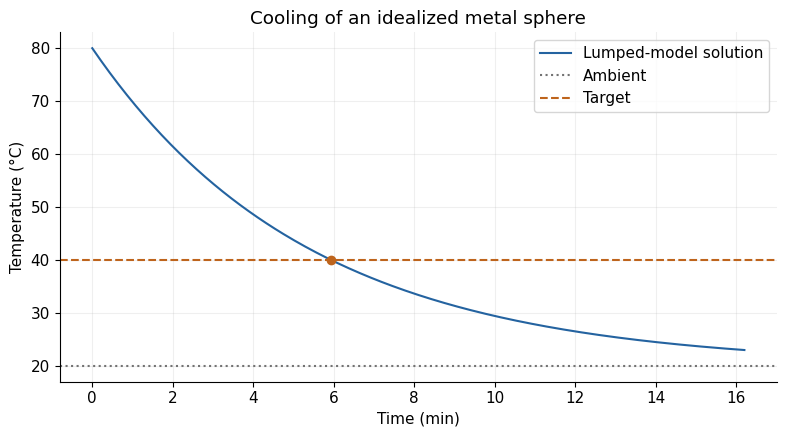

In [2]:
volume = 4.0 / 3.0 * np.pi * radius**3
area = 4.0 * np.pi * radius**2
mass = rho * volume
length_characteristic = volume / area
Bi = h * length_characteristic / k
assert Bi < 0.1, "Bi 已不够小，请不要继续用单一温度代表整个球。"
tau = mass * cp / (h * area)

def exact_temperature(time):
    return T_ambient + (T_initial - T_ambient) * np.exp(-np.asarray(time) / tau)

time_target = tau * np.log((T_initial - T_ambient) / (T_target - T_ambient))
print(f"Bi = {Bi:.6f}; time constant = {tau:.1f} s")
print(f"Target {T_target:.1f} °C reached at {time_target:.1f} s ({time_target/60:.2f} min)")

time = np.linspace(0, 3 * tau, 301)
fig, ax = plt.subplots()
ax.plot(time / 60, exact_temperature(time), color=BLUE, label="Lumped-model solution")
ax.axhline(T_ambient, color="0.45", linestyle=":", label="Ambient")
ax.axhline(T_target, color=ORANGE, linestyle="--", label="Target")
ax.scatter([time_target/60], [T_target], color=ORANGE, zorder=3)
ax.set(xlabel="Time (min)", ylabel="Temperature (°C)", title="Cooling of an idealized metal sphere")
ax.legend()
fig.tight_layout()
plt.show()


曲线开始下降较快，随后逐渐变平。在默认输入下，时间常数为 324 秒，目标时刻约 356 秒。越接近环境温度，温差越小，对流失热就越慢。

**先预测再运行**：把输入单元里的 `h` 从 25 改成 50，重新运行全部。达到目标温度的时间会怎样变化？再恢复默认值。真实流动中 h 是否恒定，仍需单独验证。

## 2. 为什么这个模型成立？
球储存的热量减少速率，等于表面向环境传出的热量速率：

$$m c_p\frac{dT}{dt}=-hA(T-T_\infty),\qquad T(0)=T_i.$$

- $mc_p$：温度每下降 1 K 释放多少能量，单位 J/K。
- $hA(T-T_\infty)$：每秒向外传多少能量，单位 W = J/s。
- $dT/dt$：当前每秒升温或降温多少，单位 K/s；冷却时为负。

温差用 °C 或 K 数值相同，因此这里可以使用 °C。将来加入 $T^4$ 辐射项时必须使用绝对温度 K。

令 $\tau=mc_p/(hA)$，方程变为 $dT/dt=-(T-T_\infty)/\tau$。它的解是

$$T(t)=T_\infty+(T_i-T_\infty)e^{-t/\tau}.$$

你可以先检查：$t=0$ 时回到初温，$t\to\infty$ 时趋于环境温度；求导后能代回原方程。求解目标时间只需整理指数再取对数。

### 方程如何对应代码
| 数学 | 代码 | 意义 |
|---|---|---|
| $V=4\pi r^3/3$ | `volume` | 球体积 |
| $A=4\pi r^2$ | `area` | 全部换热表面积 |
| $\rho V$ | `mass` | 质量 |
| $mc_p/(hA)$ | `tau` | 时间尺度 |
| $T_\infty+(T_i-T_\infty)e^{-t/\tau}$ | `exact_temperature(time)` | 模型解析解 |

### 为什么能用一个温度描述整个球？
$$Bi=\frac{hL_c}{k},\qquad L_c=V/A=r/3.$$

Bi 很小时，内部导热相对容易，球内温差可以近似忽略。常用工程判据是 Bi < 0.1；这不是对所有模型误差的保证。它也不保证辐射或物性变化一定可以忽略。

本例的 h 是输入，k 主要出现在适用性检查中。不要混淆导热系数 k 与对流换热系数 h。


## 3. 如果没有解析解，怎样一步一步算？（进阶）
用当前变化速率估计下一小段时间：

$$T_{n+1}=T_n+\Delta t\left[-\frac{T_n-T_\infty}{\tau}\right].$$

这就是显式 Euler 法。每一步只做“当前温度 + 变化速率 × 时间”。循环是沿时间向前走，没有隐藏的训练过程。

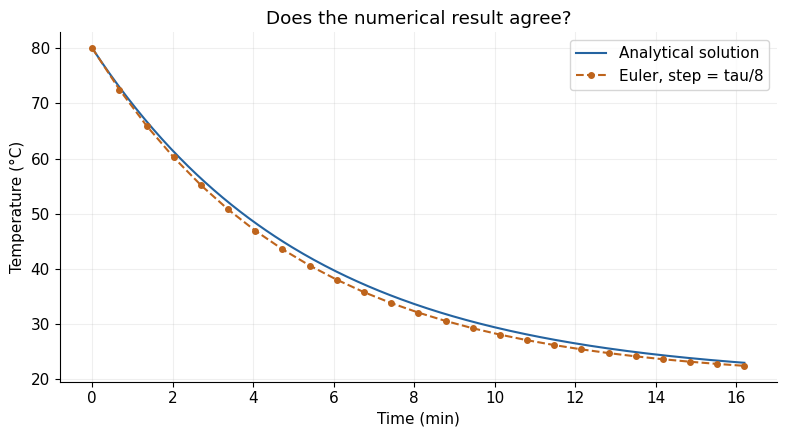

In [3]:
def euler_cooling(dt, end_time):
    if dt <= 0 or end_time <= 0:
        raise ValueError("dt 和 end_time 必须为正。")
    number_steps = int(np.ceil(end_time / dt))
    times = np.linspace(0, end_time, number_steps + 1)
    temperatures = np.empty(number_steps + 1)
    temperatures[0] = T_initial
    for index in range(number_steps):
        step = times[index + 1] - times[index]  # 最后时刻精确对齐
        rate = -(temperatures[index] - T_ambient) / tau
        temperatures[index + 1] = temperatures[index] + step * rate
    return times, temperatures

numerical_time, numerical_temperature = euler_cooling(tau / 8, 3 * tau)
fig, ax = plt.subplots()
ax.plot(time / 60, exact_temperature(time), color=BLUE, label="Analytical solution")
ax.plot(numerical_time / 60, numerical_temperature, "o--", color=ORANGE,
        markersize=4, label="Euler, step = tau/8")
ax.set(xlabel="Time (min)", ylabel="Temperature (°C)", title="Does the numerical result agree?")
ax.legend()
fig.tight_layout()
plt.show()


对于本例单调冷却且步长小于 tau 的情况，Euler 会预测得偏冷：它把每一步开始时较快的降温速率应用到整段时间。缩小步长应当改善这个误差。

Step (s)    Max absolute error (K)
  81.000       3.08839
  40.500       1.45623
  20.250       0.70832
  10.125       0.34945
   5.062       0.17358
Observed convergence orders: [1.085 1.04  1.019 1.01 ]


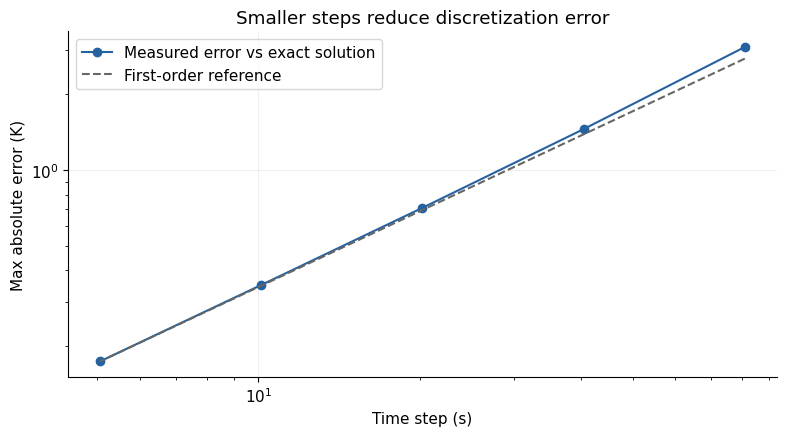

In [4]:
step_sizes = tau / np.array([4, 8, 16, 32, 64], dtype=float)
max_errors = []
print("Step (s)    Max absolute error (K)")
for step_size in step_sizes:
    ts, temperatures = euler_cooling(step_size, 3 * tau)
    error = np.max(np.abs(temperatures - exact_temperature(ts)))
    max_errors.append(error)
    print(f"{step_size:8.3f}    {error:10.5f}")
max_errors = np.array(max_errors)
orders = np.log(max_errors[:-1] / max_errors[1:]) / np.log(2)
print("Observed convergence orders:", np.round(orders, 3))
fig, ax = plt.subplots()
ax.loglog(step_sizes, max_errors, "o-", color=BLUE, label="Measured error vs exact solution")
ax.loglog(step_sizes, max_errors[-1] * step_sizes / step_sizes[-1], "--",
          color="0.4", label="First-order reference")
ax.set(xlabel="Time step (s)", ylabel="Max absolute error (K)", title="Smaller steps reduce discretization error")
ax.legend()
fig.tight_layout()
plt.show()


步长减半，误差大约减半，符合 Euler 法的一阶全局精度。图中的误差只衡量数值解对本模型解析解的偏差，**不代表对真实实验的预测误差**。

可选思考：令 $\theta=T-T_\infty$，Euler 更新为 $\theta_{n+1}=(1-\Delta t/\tau)\theta_n$。绝对稳定要求 $0<\Delta t/\tau<2$；保持不越过环境温度的单调冷却，需要 $0<\Delta t/\tau\leq1$。稳定并不等于准确。


## 4. 检查，而不是只相信曲线
下面检查初值、目标温度、长时间极限、数值误差收敛和离散能量平衡。能量检查与更新公式相容；与独立解析解对照提供另一种检查。真实物理预测仍需要测量。

In [5]:
assert np.isclose(exact_temperature(0), T_initial)
assert np.isclose(exact_temperature(time_target), T_target)
assert abs(exact_temperature(30 * tau) - T_ambient) < 1e-8
assert np.all(np.diff(max_errors) < 0)
assert 0.9 < orders[-1] < 1.2
assert np.all(np.diff(numerical_temperature) <= 0)
assert np.all(numerical_temperature >= T_ambient)
energy_released = mass * cp * (numerical_temperature[0] - numerical_temperature[-1])
energy_convected = np.sum(h * area * (numerical_temperature[:-1] - T_ambient)
                         * np.diff(numerical_time))
assert np.isclose(energy_released, energy_convected, rtol=1e-10)
print("Passed: initial/target/limit, convergence, monotonicity and discrete energy balance.")


Passed: initial/target/limit, convergence, monotonicity and discrete energy balance.


## 5. 你来完成这一课
一次只改一个变量，每次改输入后重新运行全部单元。

1. **换热更快**：h 加倍。先写预测，再运行核对。
2. **球更大**：半径加倍，其他输入不变。tau、Bi、目标时间各如何变化？这里假设 h 不随尺寸变化。
3. **从公式到代码**：指出 Euler 循环中哪一行代表导数，哪一行代表下一步温度。
4. **模型边界**：如果观察到球心和表面温度明显不同，哪个假设失效？减小时间步长能修复这个物理问题吗？

完成标准：能解释为什么冷却逐渐变慢；能分清模型误差与数值误差；能在不看答案的情况下写出 Euler 更新式。暂时不要求会推导全部微积分。

### 我的实验记录（运行后填写）
- 我改了什么：
- 我的预测：
- 实际输出：
- 为什么一致／不一致：
- 仍未理解的一个问题：

下一课可选：墙体厚度与热损失，或进一步研究 Euler 步长为什么会使结果振荡。由你的实际问题决定。

## 6. 来源与校准
- 主教材：*Fundamentals of Heat and Mass Transfer*，主题为能量守恒、对流、集总热容与 Biot 数。
- 数值教材：*Numerical Methods for Engineers*，主题为初值问题、Euler 法、误差与稳定性。
- 两本书的版次和具体题目尚未提供，未声称已对照用户教材正文，也不猜页码。
- 已核对开放来源：[MIT 18.3 Transient Heat Transfer](https://web.mit.edu/16.unified/www/SPRING/propulsion/notes/node129.html)，能量方程、指数解和时间常数；[MIT 2.005 第 6 章笔记](https://web.mit.edu/snively/www/2_005%20Coursenotes-1.pdf)，集总模型与 Bi < 0.1 判据。访问日期：2026-09-23。
- 本例为原创教学设定；所有曲线来自模型计算，无实测数据。Euler 的更新、稳定条件与误差在本 Notebook 中直接推导或实验检查。
